In [1]:
import os
import re
import glob
import unicodedata
from collections import Counter

RAW = "corpus_raw"
CLEAN = "corpus_clean"
LEMMA = "corpus_lemma"
LEXDIR = "lexicon"
BUCKETS = ("sastra", "arsip", "jurnal", "majalah")
import matplotlib.pyplot as plt


- sastra - литература (основной корпус), 
- jurnal - журналы 1920-30-х,
- arsip - архивы
- majalah - журнал Panjebar Semangat 2010-х. Тексты из папки _recovered - без категории

In [2]:
RECOVERED_JURNAL = re.compile(
    r"kajaw[eè]n|pusaka jawi|s[eê]dya tama|darma kanda|narpawandawa|"
    r"waspada|panji pustaka", re.I)
RECOVERED_ARSIP = re.compile(r"koleksi warsadiningrat|arsip", re.I)

def bucket_of(relpath, title=""):
    if relpath.startswith("sastra-org/arsip-dan-sejarah"):
        return "arsip"
    if relpath.startswith("sastra-org/koran-majalah-dan-jurnal"):
        return "jurnal"
    if relpath.startswith("sastra-org/_recovered"):
        if RECOVERED_JURNAL.search(title):
            return "jurnal"
        if RECOVERED_ARSIP.search(title):
            return "arsip"
        return "sastra"
    if relpath.startswith("panjebarsemangat/"):
        return "majalah"
    return "sastra"

Словари, грамматики и списки слов выкидываем по названию

In [3]:
EXCLUDE_TITLE = re.compile(
    r"dictionary|dictionnaire|woordenboek|wordenboek|kamus|leksikon|"
    r"paramasastra|spraakkunst|synoniemen|grammatica|dasanama|"
    r"javaansch.*taal|woordenlijst|pangkalan.?data|wawaton.?panyerat|"
    r"frekuensi.?kata", re.I)

По стоп словам определяем и выкидываем строки

In [4]:
JAV = {"ing", "kang", "iku", "ora", "lan", "saka", "karo", "wis", "ana",
       "iki", "kanthi", "dening", "marang", "sing", "ingkang", "punika",
       "menika", "wonten", "boten", "mboten", "sampun", "dhateng", "saking",
       "ugi", "inggih", "kaliyan", "dene", "yen", "menawa", "menawi",
       "nanging", "amarga", "amargi", "supaya", "supados", "banjur",
       "lajeng", "uga", "apa", "punapa", "kados", "kaya", "sarta", "tuwin",
       "utawi", "utawa", "datan", "tan", "kalawan", "miwah", "ingsun",
       "sira", "dadya", "dadi", "dados", "arsa", "badhe", "bakal", "wus",
       "sampun", "maring", "aneng", "neng", "ono", "iso", "isa", "ake",
       "dhumateng", "kagem", "dhewe", "piyambak", "malih", "maneh",
       "sanget", "banget", "mawi", "tanpa", "sajroning", "salebeting"}
IND = {"yang", "dengan", "tidak", "dari", "untuk", "pada", "adalah",
       "dalam", "dan", "akan", "sudah", "telah", "bisa", "karena",
       "mereka", "kita", "saya", "anda", "tersebut", "sebagai", "juga",
       "atau", "itu", "ini", "oleh", "ke", "di", "secara", "tetapi",
       "namun", "agar", "supaya", "jika", "kalau", "saat", "ketika",
       "sehingga", "kemudian", "yaitu", "ialah", "bahwa", "para",
       "merupakan", "terhadap", "seperti", "antara", "banyak", "lebih"}
ENG = {"the", "of", "and", "to", "in", "is", "was", "for", "with", "that",
       "this", "are", "be", "or", "from", "by", "an", "not", "his", "her"}
DUT = {"de", "het", "van", "en", "een", "der", "den", "te", "dat", "die",
       "met", "voor", "zijn", "aan", "op", "is", "niet", "ook", "naar",
       "worden", "wordt", "deze", "bij", "uit", "over", "tot"}
AMBIG = JAV & IND
JAVX, INDX = JAV - AMBIG, IND - AMBIG

PRONOUNS = {"aku", "kula", "kawula", "ingsun", "ingwang", "kowe", "kowé",
            "sira", "sampeyan", "panjenengan", "panjenenganipun",
            "dheweke", "dheke", "piyambakipun", "kita", "awakmu",
            "awakku", "slirane", "sliramu"}

Выкидываем артефакты отцифровки

In [5]:
PAGE_MARK = re.compile(r"^---\s*.+?\s*---$")
PUPUH_HEAD = re.compile(r"^\d+\.?\s+[A-Za-zÀ-ÿê]+\s*$")
NUM_ONLY = re.compile(r"^[\d\s.\-:()\[\]]+$")
EDITORIAL = re.compile(
    r"^§|teks asli\s*:|kurang satu|lebih satu|kirang sa|langkung sa|"
    r"prayoginipun|kembali\)|^sambungan$|^citra$|^judul$|tanggal masehi|"
    r"^lingkup pencarian|^teks pencarian|^filter pencarian", re.I)
BROKEN_WORD = re.compile(r"\[[^\]\[]*\.\.\.[^\]\[]*\]")
FOOTNOTE_REF = re.compile(r"\[\s*\d+\s*\]")

def is_notation_line(line):
    toks = line.split()
    if len(toks) < 3:
        return False
    dig = sum(1 for t in toks if any(c.isdigit() for c in t))
    return dig / len(toks) > 0.5

def lang_score(line):
    words = re.findall(r"[a-zà-ÿêèéåăôíìóòúùṭḍ]+", line.lower())
    j = sum(1 for w in words if w in JAVX)
    i = sum(1 for w in words if w in INDX)
    e = sum(1 for w in words if w in ENG)
    d = sum(1 for w in words if w in DUT)
    return j, i + e + d

Переводим яванский к одному виду
- нижний регистр
- сворачиваем диакритику (ê-e, å-a),
- переводим довоенную орфографию в современную (oe в u, tj в c, dj в j),
- склеиваем мягкие переносы внутри слов

In [6]:
FOLD = str.maketrans({
    "ê": "e", "è": "e", "é": "e", "ë": "e",
    "å": "a", "ă": "a", "â": "a", "à": "a", "á": "a",
    "í": "i", "ì": "i", "î": "i", "ï": "i",
    "ó": "o", "ò": "o", "ô": "o", "ö": "o",
    "ú": "u", "ù": "u", "û": "u", "ü": "u",
    "ñ": "n", "ç": "c"})

def normalize(text):
    text = text.replace("\xad", "")
    text = text.lower().translate(FOLD)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = re.sub(r"oe", "u", text)
    text = re.sub(r"tj", "c", text)
    text = re.sub(r"dj", "j", text)
    return text

Числа заменяем на ORDINAL1, местоимения на PRON1.
Дефис внутри слова сохраняем - это яванские удвоения (tata-tata).
Предложения режем по ".?!;" и по стиховым разделителям "|" и "||".

In [7]:
def tokenize(sentence):
    out = []
    for tok in re.findall(r"[a-z]+(?:-[a-z]+)*|\d+", sentence):
        if tok.isdigit():
            out.append("ORDINAL1")
        elif tok in PRONOUNS:
            out.append("PRON1")
        else:
            out.append(tok)
    return out

SENT_SPLIT = re.compile(r"(?<=[.?!;])\s+|\s*\|\|\s*|\s*\|\s*")

Очистка одного файла, по порядку:
- выкидываем мусорные строки
- оставляем только яванские (строка без стоп-слов наследует язык предыдущей)
- нормализуем
- режем на предложения (берём от 3 токенов и не "разрядку" заголовков типа "п а н г к у р")

In [8]:
def clean_file(path):
    lines = open(path, encoding="utf-8", errors="replace").read().split("\n")
    body = lines[1:]
    kept, prev_jav = [], True
    for ln in body:
        ln = ln.strip()
        if not ln:
            continue
        if (PAGE_MARK.match(ln) or NUM_ONLY.match(ln) or
                ln in ("[", "]") or EDITORIAL.search(ln) or
                PUPUH_HEAD.match(ln) or is_notation_line(ln)):
            continue
        ln = BROKEN_WORD.sub(" ", ln)
        ln = FOOTNOTE_REF.sub(" ", ln)
        j, o = lang_score(ln)
        if j + o == 0:
            keep = prev_jav
        else:
            keep = j > o
            prev_jav = keep
        if keep:
            kept.append(ln)
    sentences = []
    for ln in kept:
        for s in SENT_SPLIT.split(normalize(ln)):
            toks = tokenize(s)
            if len(toks) >= 3 and \
                    sum(1 for t in toks if len(t) == 1) <= len(toks) // 2:
                sentences.append(toks)
    return sentences

Прогон очистки по всем файлам corpus_raw (~10 минут).
Целиком выкидываем словари/грамматики и то, где после очистки осталось меньше 30 токенов (нотации гамелана, заглушки). Результат - в corpus_clean.

In [9]:
os.makedirs(CLEAN, exist_ok=True)
excluded, stats = [], Counter()
corp_text = {b: open(os.path.join(CLEAN, f"corpus_text_{b}.txt"), "w",
                     encoding="utf-8") for b in BUCKETS}
corp_seg = {b: open(os.path.join(CLEAN, f"corpus_segments_{b}.txt"), "w",
                    encoding="utf-8") for b in BUCKETS}

for dirp, _, files in os.walk(RAW):
    for fn in sorted(files):
        if not fn.endswith(".txt") or fn.startswith("_"):
            continue
        src = os.path.join(dirp, fn)
        rel = os.path.relpath(src, RAW)
        title = open(src, encoding="utf-8", errors="replace").readline().strip()
        if EXCLUDE_TITLE.search(title) or EXCLUDE_TITLE.search(fn):
            excluded.append((rel, "dictionary/grammar/wordlist"))
            continue
        b = bucket_of(rel, title)
        sents = clean_file(src)
        ntok = sum(len(s) for s in sents)
        if ntok < 30:
            excluded.append((rel, f"too short after cleaning ({ntok} tok)"))
            continue
        flat = rel.replace("/", "__")
        os.makedirs(os.path.join(CLEAN, "texts", b), exist_ok=True)
        with open(os.path.join(CLEAN, "texts", b, flat), "w",
                  encoding="utf-8") as f:
            for s in sents:
                f.write(" ".join(s) + "\n")
        corp_text[b].write(" ".join(" ".join(s) for s in sents) + "\n")
        for s in sents:
            corp_seg[b].write(" ".join(s) + "\n")
        stats[b + "_files"] += 1
        stats[b + "_tokens"] += ntok
        stats[b + "_sents"] += len(sents)

for f in list(corp_text.values()) + list(corp_seg.values()):
    f.close()
with open(os.path.join(CLEAN, "_excluded.tsv"), "w", encoding="utf-8") as f:
    f.write("file\treason\n")
    for r, why in excluded:
        f.write(f"{r}\t{why}\n")
with open(os.path.join(CLEAN, "_stats.txt"), "w", encoding="utf-8") as f:
    for k in sorted(stats):
        f.write(f"{k}: {stats[k]}\n")
    f.write(f"excluded_files: {len(excluded)}\n")

for k in sorted(stats):
    print(f"{k}: {stats[k]}")
print("исключено файлов:", len(excluded))

arsip_files: 386
arsip_sents: 181199
arsip_tokens: 1630948
jurnal_files: 682
jurnal_sents: 299590
jurnal_tokens: 3834223
majalah_files: 2224
majalah_sents: 126512
majalah_tokens: 1234437
sastra_files: 2105
sastra_sents: 2254719
sastra_tokens: 13830816
исключено файлов: 792


Лемматизация. Принцип: сними аффикс - проверь, что получился существующий корень.
Лексикон корней собираем из словарей, лежащих в сыром корпусе (в текстовый корпус они не вошли, а тут пригодились):
- Javanese-English Dictionary, E. C. Horne, 1974 (заголовочные слова; основной современный словарь, 31 файл со sastra.org)
- Javaansch-Nederduitsch Woordenboek, Gericke & Roorda, 1847 (20 частей; самый полный словарь яванского XIX века, даёт классическую лексику; перенаправления "zie X" не берём)
- списки синонимов dasanama - старинная поэтическая лексика (кави): Dasanama Kawi (Padmasusastra, 1897), Kawi Dasanama (Winter, 1875; аноним, 1882), Dasanamajarwa (Dirjaatmaja, 1913 и 1916; Tjokrodipuro, 1970), Dasanama mawi Jarwa (аноним, 1904), Dasanama (аноним, 1932; Dwijo, 1950)

Заодно считаем частоты слов корпуса - пригодятся для выбора между кандидатами.

In [10]:
WORD = re.compile(r"^[a-zà-ÿêèéåăṭḍ]+(?:-[a-zà-ÿêèéåăṭḍ]+)*$")
HORNE_NOISE = {"a", "b", "c", "ng", "kr", "ki", "ka", "var", "rg", "ltry",
               "inf", "sms", "see", "also", "or", "oj", "kn", "md"}

def horne_headwords():
    words = set()
    files = glob.glob(os.path.join(
        RAW, "sastra-org", "*", "*javanese-english-dictionary-horne*.txt"))
    for path in files:
        for ln in open(path, encoding="utf-8", errors="replace"):
            w = ln.strip().lower()
            if (not w or " " in w or len(w) < 3 or w in HORNE_NOISE or
                    w.startswith("-") or w.endswith("-")):
                continue
            if WORD.match(w):
                words.add(normalize(w))
    return words

def dasanama_words():
    words = set()
    files = glob.glob(os.path.join(RAW, "sastra-org", "*", "*dasanama*.txt"))
    for path in files:
        for ln in open(path, encoding="utf-8", errors="replace"):
            ln = ln.strip()
            if ln.startswith("---"):
                continue
            if ln.endswith(":") and len(ln.split()) <= 3:
                ln = ln.rstrip(" :")
            elif "|" not in ln:
                continue
            for w in re.split(r"[|,.()]| ", ln):
                w = w.strip().lower()
                if len(w) >= 3 and WORD.match(w):
                    words.add(normalize(w))
    return words

def gericke_headwords():
    words = set()
    files = glob.glob(os.path.join(RAW, "sastra-org", "*", "*gericke*.txt"))
    for path in files:
        lines = [l.strip() for l in
                 open(path, encoding="utf-8", errors="replace")]
        for i, ln in enumerate(lines):
            if not ln.endswith(":"):
                continue
            w = ln.rstrip(" :").lower()
            if len(w) < 3 or not WORD.match(w):
                continue
            nxt = lines[i + 1] if i + 1 < len(lines) else ""
            if nxt.lower().startswith("zie ") and len(nxt) < 60:
                continue
            words.add(normalize(w))
    return words

os.makedirs(LEXDIR, exist_ok=True)
horne = horne_headwords()
dasa = dasanama_words()
gericke = gericke_headwords()
roots_all = horne | dasa | gericke
with open(os.path.join(LEXDIR, "roots.txt"), "w", encoding="utf-8") as f:
    for w in sorted(roots_all):
        f.write(w + "\n")

freq_cnt = Counter()
for b in BUCKETS:
    p = os.path.join(CLEAN, f"corpus_segments_{b}.txt")
    if os.path.exists(p):
        for ln in open(p, encoding="utf-8"):
            freq_cnt.update(ln.split())
with open(os.path.join(LEXDIR, "freq.tsv"), "w", encoding="utf-8") as f:
    for w, c in freq_cnt.most_common():
        if c >= 3:
            f.write(f"{w}\t{c}\n")

print(f"Horne: {len(horne)}, dasanama: {len(dasa)}, "
      f"Gericke-Roorda: {len(gericke)}, корней: {len(roots_all)}")

Horne: 12362, dasanama: 5583, Gericke-Roorda: 9293, корней: 22421


Правила снятия аффиксов:
- назальный префикс N- съедает первую согласную корня (nulis ← tulis), её восстанавливаем перебором кандидатов
- обычные префиксы (di-, ka-, sa-...) и суффиксы (-e/-ipun, -ake/-aken, -an, стиховые -(n)ing и -(n)ira...)
- инфиксы -um-/-in- внутри слова (tinulis → tulis)
- удвоения (omah-omah → omah, lelaku → laku)

In [11]:
SUFFIXES = ["kaken", "nipun", "kake", "ipun", "aken", "ake", "ning",
            "nira", "ana", "ing", "ira", "na", "ne", "en", "an",
            "e", "i", "a", "ku", "mu"]
PREFIXES = ["dipun", "di", "ka", "ke", "tak", "dak", "kok", "sa",
            "pa", "pi", "pra", "kuma", "a"]
SPECIALS = {"ORDINAL1", "PRON1"}

def nasal_candidates(w):
    out = []
    if w.startswith("nj"):
        out.append(w[1:])
    elif w.startswith("nge") and len(w) <= 7:
        out.append(w[3:])
    if w.startswith("ng"):
        out.append(w[2:])
        out.append("k" + w[2:])
    elif w.startswith("ny"):
        out.append("s" + w[2:])
        out.append("c" + w[2:])
    elif w.startswith("mb") or (len(w) > 1 and w[0] == "m" and w[1] in "lr"):
        out.append(w[1:])
    elif w.startswith("m"):
        out.append("p" + w[1:])
        out.append("w" + w[1:])
    elif w.startswith("nd"):
        out.append(w[1:])
    elif w.startswith("n"):
        out.append("t" + w[1:])
        out.append("th" + w[1:])
    return out

def strip_candidates(w):
    out = []
    if "-" in w:
        parts = w.split("-")
        if len(parts) == 2 and parts[0] and parts[1]:
            if parts[0] == parts[1]:
                out.append(parts[1])
            elif len(parts[0]) == len(parts[1]):
                out.append(parts[1])
        return out
    if len(w) > 4 and w[0] == w[2] and w[1] in "ea":
        out.append(w[2:])
    for s in SUFFIXES:
        if w.endswith(s) and len(w) - len(s) >= 3:
            out.append(w[:-len(s)])
    for p in PREFIXES:
        if w.startswith(p) and len(w) - len(p) >= 3:
            out.append(w[len(p):])
    out.extend(c for c in nasal_candidates(w) if len(c) >= 3)
    if len(w) >= 5 and w[1:3] in ("um", "in"):
        out.append(w[0] + w[3:])
    return out

Сам лемматизатор: поиск в ширину, цепочки до 3 снятий. Первый уровень, где нашёлся корень из лексикона, даёт лемму (из нескольких кандидатов берём самый частотный). Ничего не нашли - оставляем слово как есть, чтобы не испортить.
Очень частые короткие слова не трогаем (это служебные), редкие трёхбуквенные корни не принимаем (среди них много ложных).

In [12]:
class Lemmatizer:
    def __init__(self, lexdir=LEXDIR):
        self.roots = set(
            open(os.path.join(lexdir, "roots.txt"), encoding="utf-8")
            .read().split())
        self.freq = {}
        for ln in open(os.path.join(lexdir, "freq.tsv"), encoding="utf-8"):
            w, c = ln.rsplit("\t", 1)
            self.freq[w] = int(c)
        self.roots |= {w for w, c in self.freq.items()
                       if c >= 3000 and 3 <= len(w) <= 7 and w.isalpha()}
        self.cache = {}

    def lemma(self, tok):
        if tok in SPECIALS or len(tok) < 4 or tok in self.roots:
            return tok
        if self.freq.get(tok, 0) >= 5000 and len(tok) <= 7:
            return tok
        if tok in self.cache:
            return self.cache[tok]
        best, frontier, seen = None, [tok], {tok}
        for depth in range(1, 4):
            nxt = []
            for w in frontier:
                for c in strip_candidates(w):
                    if c in seen or len(c) < 3:
                        continue
                    seen.add(c)
                    nxt.append(c)
            hits = [c for c in nxt if c in self.roots and
                    (len(c) >= 4 or self.freq.get(c, 0) >= 500)]
            if hits:
                best = max(hits, key=lambda c: (self.freq.get(c, 0), len(c)))
                break
            frontier = nxt
            if not frontier:
                break
        res = best if best else tok
        self.cache[tok] = res
        return res

lem = Lemmatizer()
print(lem.lemma("panulisan"), lem.lemma("dipunserat"), lem.lemma("gumuyu"))

tulis serat guyu


Что дала лемматизация: сравниваем словарь до и после по зонам частот (основной корпус sastra).
Общее число разных слов - обманчивая метрика: половина словаря - слова, встреченные 1 раз (опечатки оцифровки, имена, разовые архаизмы), их никакой лемматизатор не склеит. А вот в содержательной зоне (частота >= 5 - то, что пойдёт в эмбеддинги) словарь ужимается почти вдвое.

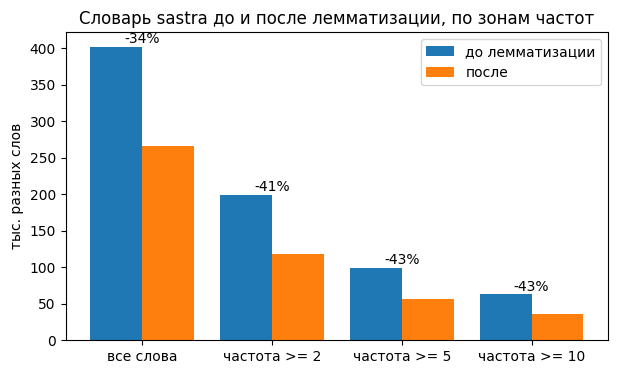

In [13]:
before_cnt, after_cnt = Counter(), Counter()
for ln in open(os.path.join(CLEAN, "corpus_segments_sastra.txt"),
               encoding="utf-8"):
    before_cnt.update(ln.split())
for ln in open(os.path.join(LEMMA, "corpus_segments_sastra.txt"),
               encoding="utf-8"):
    after_cnt.update(ln.split())

thresholds = [1, 2, 5, 10]
labels = ["все слова", "частота >= 2", "частота >= 5", "частота >= 10"]
b_vals = [sum(1 for c in before_cnt.values() if c >= t) / 1000
          for t in thresholds]
a_vals = [sum(1 for c in after_cnt.values() if c >= t) / 1000
          for t in thresholds]

x = range(len(labels))
plt.figure(figsize=(7, 4))
plt.bar([i - 0.2 for i in x], b_vals, width=0.4, label="до лемматизации")
plt.bar([i + 0.2 for i in x], a_vals, width=0.4, label="после")
for i in x:
    plt.text(i, max(b_vals[i], a_vals[i]) + 5,
             f"-{100 * (1 - a_vals[i] / b_vals[i]):.0f}%", ha="center")
plt.xticks(x, labels)
plt.ylabel("тыс. разных слов")
plt.title("Словарь sastra до и после лемматизации, по зонам частот")
plt.legend()
plt.show()

Проверка качества на трибанке UD Javanese-CSUI с эталонными леммами (необязательный шаг, файл лежит в eval/). Точность около 87%; часть расхождений - просто другие конвенции разметки UD (там леммируют даже устоявшиеся слова: gamelan → gamel).

In [14]:
def evaluate(conllu_path):
    total = correct = affixed = affixed_ok = 0
    for ln in open(conllu_path, encoding="utf-8"):
        cols = ln.split("\t")
        if len(cols) != 10 or not cols[0].isdigit():
            continue
        form, gold = cols[1].lower(), cols[2].lower()
        if not form.isalpha() or cols[3] in ("PUNCT", "SYM", "NUM", "PROPN"):
            continue
        f, g = normalize(form), normalize(gold)
        p = lem.lemma(f)
        total += 1
        correct += p == g
        if f != g:
            affixed += 1
            affixed_ok += p == g
    print(f"токенов: {total}, точность: {correct / total:.3f}, "
          f"на аффиксированных: {affixed_ok / affixed:.3f}")

if os.path.exists("eval/jv_csui-ud-test.conllu"):
    evaluate("eval/jv_csui-ud-test.conllu")

токенов: 9968, точность: 0.873, на аффиксированных: 0.532


На выходе:
- corpus_clean/ - очищенный корпус
- lexicon/ - корни и частоты
- corpus_lemma/ - очищенный и лемматизированный корпус: в каждом ведре texts/<ведро>/ (тексты по файлам), corpus_text_<ведро>.txt (для SVD) и corpus_segments_<ведро>.txt (для CBoW)

Основной корпус для эмбеддингов - ведро sastra. Дальше - SVD (размерность не больше 32) и CBoW.

In [15]:
freqs, slens = {}, {}
for b in BUCKETS:
    p = os.path.join(LEMMA, f"corpus_segments_{b}.txt")
    if not os.path.exists(p):
        continue
    cnt, lens = Counter(), []
    for ln in open(p, encoding="utf-8"):
        toks = ln.split()
        cnt.update(toks)
        lens.append(len(toks))
    freqs[b], slens[b] = cnt, lens

print(f"{'ведро':<9}{'текстов':>9}{'предлож.':>11}{'токенов':>13}"
      f"{'слов(типов)':>13}{'ср.предл.':>11}")
for b in freqs:
    ntexts = len(os.listdir(os.path.join(LEMMA, "texts", b)))
    ntok = sum(freqs[b].values())
    print(f"{b:<9}{ntexts:>9}{len(slens[b]):>11}{ntok:>13}"
          f"{len(freqs[b]):>13}{ntok / len(slens[b]):>11.1f}")

ведро      текстов   предлож.      токенов  слов(типов)  ср.предл.
sastra        2105    2254719     13830816       266323        6.1
arsip          386     181199      1630948        48647        9.0
jurnal         682     299590      3834223        85395       12.8
majalah       2224     126512      1234437        54036        9.8


In [16]:
total = sum(freqs["sastra"].values())
for i, (w, c) in enumerate(freqs["sastra"].most_common(30), 1):
    print(f"{i:>3}. {w:<12} {c:>9}  ({100 * c / total:.2f}%)")

  1. ing             365913  (2.65%)
  2. kang            271630  (1.96%)
  3. PRON1           188849  (1.37%)
  4. ORDINAL1        156351  (1.13%)
  5. ingkang         144984  (1.05%)
  6. sang            108960  (0.79%)
  7. tan              93712  (0.68%)
  8. wong             92494  (0.67%)
  9. lan              91130  (0.66%)
 10. yen              82423  (0.60%)
 11. wus              81746  (0.59%)
 12. sampun           74904  (0.54%)
 13. iku              63691  (0.46%)
 14. punika           59634  (0.43%)
 15. sami             58901  (0.43%)
 16. ana              57664  (0.42%)
 17. wonten           50682  (0.37%)
 18. dhateng          49717  (0.36%)
 19. lajeng           48842  (0.35%)
 20. mring            46235  (0.33%)
 21. saking           46050  (0.33%)
 22. para             45317  (0.33%)
 23. marang           44233  (0.32%)
 24. ki               43271  (0.31%)
 25. prabu            43159  (0.31%)
 26. wau              42457  (0.31%)
 27. ora              42388  (0.31%)
 

Размер корпуса по вёдрам, в миллионах токенов.

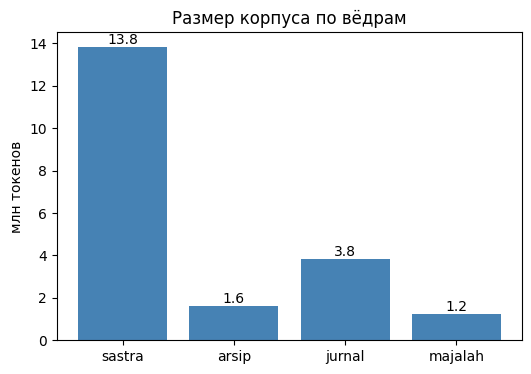

In [17]:
names = list(freqs)
toks = [sum(freqs[b].values()) / 1e6 for b in names]
plt.figure(figsize=(6, 4))
plt.bar(names, toks, color="steelblue")
for i, v in enumerate(toks):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.ylabel("млн токенов")
plt.title("Размер корпуса по вёдрам")
plt.show()

20 самых частых слов основного корпуса

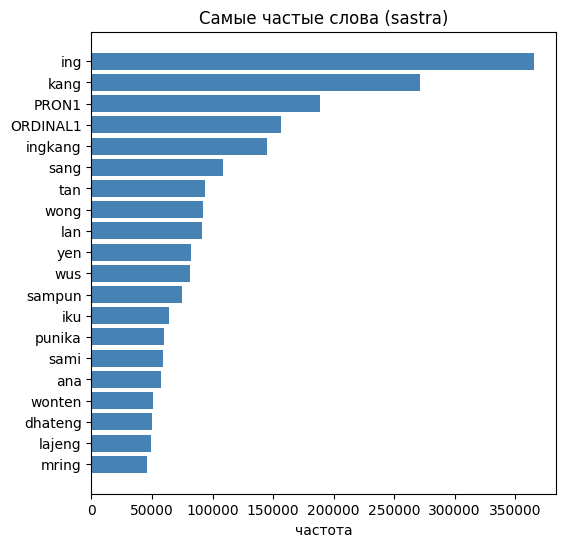

In [18]:
words, cnts = zip(*freqs["sastra"].most_common(20))
plt.figure(figsize=(6, 6))
plt.barh(words, cnts, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("частота")
plt.title("Самые частые слова (sastra)")
plt.show()

Что дала лемматизация: сколько разных слов было в каждом ведре до неё и сколько осталось после. Разные формы одного корня склеились в одну лемму.

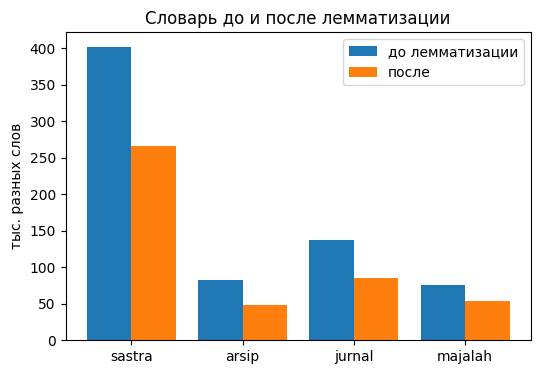

In [19]:
vocab = {}
for ln in open(os.path.join(LEMMA, "_stats.txt"), encoding="utf-8"):
    if "_vocab" in ln:
        b = ln.split("_vocab")[0]
        before, after = ln.split(":")[1].split("->")
        vocab[b] = (int(before), int(after))

names = list(vocab)
x = range(len(names))
plt.figure(figsize=(6, 4))
plt.bar([i - 0.2 for i in x], [vocab[b][0] / 1000 for b in names],
        width=0.4, label="до лемматизации")
plt.bar([i + 0.2 for i in x], [vocab[b][1] / 1000 for b in names],
        width=0.4, label="после")
plt.xticks(x, names)
plt.ylabel("тыс. разных слов")
plt.title("Словарь до и после лемматизации")
plt.legend()
plt.show()

Эффективность лемматизатора по эталону UD, подробно. Раскладываем все слова эталона: какие менять не надо (и не тронули ли мы их зря), какие надо - и что мы с ними сделали. Главное: когда лемматизатор решается тронуть слово, он почти всегда прав (ложных замен ~3%); его слабое место - охват (часть аффиксированных слов не разбирается, потому что корня нет в лексиконе).

 7515 (75.4%)  менять не надо: верно оставили
 1192 (12.0%)  менять надо: тронули верно
  429 ( 4.3%)  менять надо: не разобрали (корня нет в лексиконе)
  419 ( 4.2%)  менять надо: сознательно оставили (служебное/словарное)
  211 ( 2.1%)  менять не надо: ЗРЯ ТРОНУЛИ
  202 ( 2.0%)  менять надо: тронули иначе

из всех наших замен верны: 74%


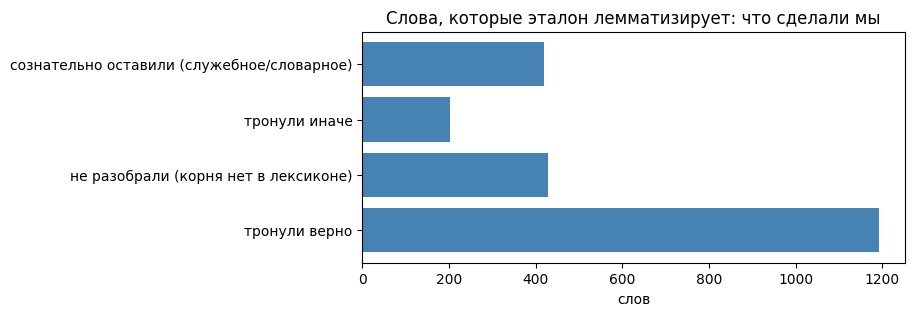

In [20]:
stat = Counter()
for ln in open("eval/jv_csui-ud-test.conllu", encoding="utf-8"):
    cols = ln.split("\t")
    if len(cols) != 10 or not cols[0].isdigit():
        continue
    form, gold = cols[1].lower(), cols[2].lower()
    if not form.isalpha() or cols[3] in ("PUNCT", "SYM", "NUM", "PROPN"):
        continue
    f, g = normalize(form), normalize(gold)
    p = lem.lemma(f)
    if g == f:
        stat["менять не надо: верно оставили" if p == f
             else "менять не надо: ЗРЯ ТРОНУЛИ"] += 1
    else:
        if p == g:
            stat["менять надо: тронули верно"] += 1
        elif p != f:
            stat["менять надо: тронули иначе"] += 1
        elif f in lem.roots or (lem.freq.get(f, 0) >= 5000 and len(f) <= 7) \
                or len(f) < 4:
            stat["менять надо: сознательно оставили (служебное/словарное)"] += 1
        else:
            stat["менять надо: не разобрали (корня нет в лексиконе)"] += 1

total = sum(stat.values())
for k, v in stat.most_common():
    print(f"{v:>5} ({100 * v / total:4.1f}%)  {k}")

changed = sum(v for k, v in stat.items() if "тронули" in k or "ЗРЯ" in k)
print(f"\nиз всех наших замен верны: "
      f"{100 * stat['менять надо: тронули верно'] / changed:.0f}%")

labels = [k.split(": ")[1] for k in stat if k.startswith("менять надо")]
vals = [stat[k] for k in stat if k.startswith("менять надо")]
plt.figure(figsize=(7, 3))
plt.barh(labels, vals, color="steelblue")
plt.title("Слова, которые эталон лемматизирует: что сделали мы")
plt.xlabel("слов")
plt.show()

Известные проблемы и ограничения.

Лемматизатор:
- принцип "не нашёл корень - не трогай": склеивает не всё. Формы, чьего корня нет в лексиконе (а в нём ~17 тыс. корней), остаются как есть - поэтому после лемматизации всё равно сотни тысяч разных слов (304 тыс. в sastra): хапаксы, имена, редкое кави, шум оцифровки
- обратная сторона: изредка ошибается на именах собственных (lamongan → lamong) - после lowercase имя не отличить от обычного слова
- не разворачивает стяжения гласных на стыке морфем (turu + an → turon)
- с эталоном UD совпадает 87%, из наших замен верны ~74%; часть расхождений - просто другие конвенции UD (там леммируют даже устоявшиеся слова: gamelan → gamel)

Стили (ngoko/krama):
- грамматику регистров сводим (-e и -ipun дают одну лемму), а лексические пары сознательно не переводим: mangan / nedha / dhahar - три разные леммы. Из-за этого частота "одного смысла" размазана по 2-3 словам
- значит, у эмбеддингов отдельный тест качества: регистровые пары должны получить близкие векторы. Слепая замена krama в ngoko испортила бы данные (соответствия не один-к-одному и зависят от того, о ком речь)

Ещё важное:
- перекос состава: большая часть основного корпуса - классический стих XVIII - начала XX века, современный язык представлен слабо. Эмбеддинги получатся "литературно-архаичными"
- дубли произведений: часть классики есть в 2+ изданиях/транскрипциях (Centhini 1912 и 1985-91) - это разные тексты, не копии, но лексика частично задвоена
- стиховые сегменты короткие (в среднем ~6 токенов - это строки строф): у крайних слов мало контекста для CBoW, плюс в стихах инверсии ради метра
- шум оцифровки: 54% словаря - слова, встреченные 1 раз (опечатки, разнобой старых написаний); лечится частотным порогом при обучении эмбеддингов
- старая орфография: букву j (= "й") в довоенных текстах нельзя автоматически отличить от j (= "дж"), поэтому в журнальном ведре часть слов задвоена (kaja / kaya)